In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

files_to_check = [
    '../data/2025 County Health Rankings Data - v4.xlsx',
    '../data/BCD_HPSA_FCT_DET_PC.csv',
]

for f in files_to_check:
    exists = os.path.exists(f)
    print(f"{'FOUND' if exists else 'MISSING'}: {f}")

print("\nCurrent working directory:", os.getcwd())

FOUND: ../data/2025 County Health Rankings Data - v4.xlsx
FOUND: ../data/BCD_HPSA_FCT_DET_PC.csv

Current working directory: C:\Users\gaine\OneDrive\Desktop\NSS\capstone\notebooks


In [3]:
chr_df = pd.read_excel('../data/2025 County Health Rankings Data - v4.xlsx', 
                        sheet_name=1, 
                        header=1)
print("CHR Shape:", chr_df.shape)
chr_df.head()

CHR Shape: (3210, 225)


,FIPS,State,County,Unreliable,Deaths,Years of Potential Life Lost Rate,95% CI - Low,95% CI - High,National Z-Score,YPLL Rate (Hispanic (all races)),...,Injury Death Rate (Non-Hispanic 2+ races) 95% CI - Low,Injury Death Rate (Non-Hispanic 2+ races) 95% CI - High,Injury Death Rate (Non-Hispanic White),Injury Death Rate (Non-Hispanic White) 95% CI - Low,Injury Death Rate (Non-Hispanic White) 95% CI - High,# Associations,Social Association Rate,National Z-Score.27,% Household Income Required for Child Care Expenses,National Z-Score.28
0,1000,Alabama,NaN,NaN,102760.0,11853.247248,11744.014820,11962.479676,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5916.0,11.658760,NaN,25.547114,NaN
1,1001,Alabama,Autauga,NaN,1008.0,9938.263382,9021.297133,10855.229632,-0.144182,NaN,...,NaN,NaN,66.353516,55.322574,77.384459,67.0,11.211700,0.043429,21.835108,-0.961825
2,1003,Alabama,Baldwin,NaN,3944.0,8957.112686,8499.339223,9414.886148,-0.400274,4636.48424,...,NaN,NaN,86.954622,81.060141,92.849104,239.0,9.698298,0.308739,19.354057,-1.316051
3,1005,Alabama,Barbour,NaN,587.0,12738.656137,11133.499025,14343.813250,0.586752,NaN,...,NaN,NaN,92.500356,69.083690,121.301910,22.0,8.904720,0.447859,28.579628,0.001105
4,1007,Alabama,Bibb,NaN,509.0,11708.948038,10166.716823,13251.179253,0.317987,NaN,...,NaN,NaN,110.157489,88.691939,135.248986,19.0,8.634401,0.495248,26.582776,-0.283990


I loaded and cleaned CHR (County Health Rankings)

Loaded the County Health Rankings file and filtered down to just my 13 Southern
states of interest.

Found two problems with the FIPS column: it included state-level summary rows
(no County value, just a state total), and it was stored as a number instead of
text, so it dropped leading zeros on states like Alabama.

Dropped the state-level rows and zero-padded FIPS back to 5 digits so it will
match the FIPS format in HPSA and MUA/P for merging later.

In [4]:
chr_df = chr_df[chr_df['County'].notna()]

chr_df['FIPS'] = chr_df['FIPS'].astype(str).str.zfill(5)

print("New CHR shape:", chr_df.shape)
chr_df[['FIPS', 'State', 'County']].head()

New CHR shape: (3159, 225)


,FIPS,State,County
1,01001,Alabama,Autauga
2,01003,Alabama,Baldwin
3,01005,Alabama,Barbour
4,01007,Alabama,Bibb
5,01009,Alabama,Blount


In [5]:
chr_df['FIPS'].str.len().value_counts()

FIPS
5    3159
Name: count, dtype: int64

In [6]:
southern_states = ['Alabama', 'Arkansas', 'Florida', 'Georgia', 
                   'Kentucky', 'Louisiana', 'Mississippi', 
                   'North Carolina', 'South Carolina', 
                   'Tennessee', 'Texas', 'Virginia', 'West Virginia']

chr_south = chr_df[chr_df['State'].isin(southern_states)]
print(chr_south.shape)

(1318, 225)


I loaded and cleaned HPSA (Primary Care Shortage Areas)

Loaded the HPSA file with `low_memory=False` to stop pandas from guessing column
types in chunks, it was flagging 3 columns as "mixed type" when they were really
just FIPS codes being read inconsistently.

Checked those 3 flagged columns directly, confirmed all FIPS-code columns are
strings, which is correct (FIPS codes need their leading zeros, so they can't be
numbers).

Found 4 exact duplicate rows and dropped them. Final shape: 79,052 rows × 66 columns.

In [7]:
hpsa_df = pd.read_csv('../data/BCD_HPSA_FCT_DET_PC.csv', encoding='latin-1', low_memory=False)
print("HPSA Shape:", hpsa_df.shape)
hpsa_df.head()

HPSA Shape: (79056, 66)


,HPSA Name,HPSA ID,Designation Type,HPSA Discipline Class,HPSA Score,PC MCTA Score,Primary State Abbreviation,HPSA Status,HPSA Designation Date,HPSA Designation Last Update Date,...,Rural Status Code,State Abbreviation,State and County Federal Information Processing Standard Code,State FIPS Code,State Name,U.S. - Mexico Border 100 Kilometer Indicator,U.S. - Mexico Border County Indicator,Data Warehouse Record Create Date,Data Warehouse Record Create Date Text,Unnamed: 65
0,RUTGERS THE STATE UNIVERSITY OF NEW JERSEY,1347143042,Federally Qualified Health Center,Primary Care,6,10.0,NJ,Designated,05/17/2024,05/13/2025,...,N,NJ,34013,34,New Jersey,N,N,06/11/2026,2026/06/11,NaN
1,Salem City SA,1347035283,Geographic HPSA,Primary Care,18,15.0,NJ,Designated,08/07/2025,08/07/2025,...,N,NJ,34033,34,New Jersey,N,N,06/11/2026,2026/06/11,NaN
2,Bayside State Prison,1346602983,Correctional Facility,Primary Care,12,0.0,NJ,Designated,05/30/2013,05/24/2022,...,R,NJ,34011,34,New Jersey,N,N,06/11/2026,2026/06/11,NaN
3,South Essex County SA,1346542462,Geographic HPSA,Primary Care,13,9.0,NJ,Designated,02/25/2026,02/25/2026,...,N,NJ,34013,34,New Jersey,N,N,06/11/2026,2026/06/11,NaN
4,South Essex County SA,1346542462,Geographic HPSA,Primary Care,13,9.0,NJ,Designated,02/25/2026,02/25/2026,...,N,NJ,34013,34,New Jersey,N,N,06/11/2026,2026/06/11,NaN


In [8]:
for col in hpsa_df.columns[[29, 53, 59]]:
    print(col, hpsa_df[col].apply(type).value_counts())

Common State FIPS Code Common State FIPS Code
<class 'str'>    79056
Name: count, dtype: int64
Primary State FIPS Code Primary State FIPS Code
<class 'str'>    79056
Name: count, dtype: int64
State FIPS Code State FIPS Code
<class 'str'>    79056
Name: count, dtype: int64


In [9]:
hpsa_df.duplicated().sum()

np.int64(4)

In [10]:
hpsa_df['State FIPS Code'].str.len().value_counts()

State FIPS Code
2    79056
Name: count, dtype: int64

In [11]:
hpsa_df = hpsa_df.drop_duplicates()
print("New shape:", hpsa_df.shape)

New shape: (79052, 66)


I loaded and cleaned (Medically Underserved Areas/Populations)

Loaded the MUA/P file the same way as HPSA, low_memory=False to avoid the same
mixed-type warning. Checked the 3 flagged columns directly and confirmed they're
all FIPS-related strings, same as before.

I noticed repeated MUA/P IDs at first and almost treated them as duplicates like
HPSA, but they're not. One designation can cover multiple counties, so the same
ID showing up more than once is expected structure, not an error.

Checked for true full-row duplicates instead and found 4. Dropped them.
Final shape: 19,733 rows × 65 columns.


In [12]:
mua_df = pd.read_csv('../data/MUA_DET.csv', encoding='latin-1', low_memory=False)
print("MUA Shape:", mua_df.shape)
mua_df.head()

MUA Shape: (19737, 65)


,MUA/P ID,MUA/P Area Code,MUA/P Service Area Name,Designation Type Code,Designation Type,MUA/P Status Code,MUA/P Status Description,Designation Date,MUA/P Designation Date String,MUA/P Update Date,...,Common Region Code,Common Region Name,Common State Name,Common State Abbreviation,Common State FIPS Code,Common State County FIPS Code,Common County Name,Data Warehouse Record Create Date,Data Warehouse Record Create Date Text,Unnamed: 64
0,1512420473,51015,Augusta-Staunton-Waynesboro MUP,MUP,Medically Underserved Population,D,Designated,03/23/2022,2022/03/23,03/23/2022,...,3,Region 3,Virginia,VA,51,51015,"Augusta County, VA",06/10/2026,2026/06/10,NaN
1,1512420473,51790,Augusta-Staunton-Waynesboro MUP,MUP,Medically Underserved Population,D,Designated,03/23/2022,2022/03/23,03/23/2022,...,3,Region 3,Virginia,VA,51,51790,"Staunton City, VA",06/10/2026,2026/06/10,NaN
2,1512420473,51820,Augusta-Staunton-Waynesboro MUP,MUP,Medically Underserved Population,D,Designated,03/23/2022,2022/03/23,03/23/2022,...,3,Region 3,Virginia,VA,51,51820,"Waynesboro City, VA",06/10/2026,2026/06/10,NaN
3,1512383216,51175,Southampton/Franklin City,MUA,Medically Underserved Area,D,Designated,11/01/2025,2025/11/01,11/01/2025,...,3,Region 3,Virginia,VA,51,51175,"Southampton County, VA",06/10/2026,2026/06/10,NaN
4,1512383216,51620,Southampton/Franklin City,MUA,Medically Underserved Area,D,Designated,11/01/2025,2025/11/01,11/01/2025,...,3,Region 3,Virginia,VA,51,51620,"Franklin City, VA",06/10/2026,2026/06/10,NaN


In [13]:
 for col in mua_df.columns[[27, 28, 60]]:
    print(col, mua_df[col].apply(type).value_counts())

State and County Federal Information Processing Standard Code State and County Federal Information Processing Standard Code
<class 'str'>    19737
Name: count, dtype: int64
County or County Equivalent Federal Information Processing Standard Code County or County Equivalent Federal Information Processing Standard Code
<class 'str'>    19737
Name: count, dtype: int64
Common State County FIPS Code Common State County FIPS Code
<class 'str'>    19737
Name: count, dtype: int64


In [14]:
mua_df['Common State County FIPS Code'].str.len().value_counts()

Common State County FIPS Code
5    19737
Name: count, dtype: int64

In [15]:
mua_df.duplicated().sum()  

np.int64(4)

In [16]:
mua_df = mua_df.drop_duplicates()
print("New MUA shape:", mua_df.shape)

New MUA shape: (19733, 65)


In [17]:
cms_df_raw = pd.read_csv('../data/FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv', encoding='latin-1', low_memory=False)
print("CMS Shape:", cms_df_raw.shape)
cms_df_raw.head()

CMS Shape: (18330, 12)


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


In [18]:
cardiac_measures = ['READM-30-AMI-HRRP', 'READM-30-HF-HRRP', 'READM-30-CABG-HRRP']
cms_df = cms_df_raw[cms_df_raw['Measure Name'].isin(cardiac_measures)]
print("Cardiac-only shape:", cms_df.shape)

Cardiac-only shape: (9165, 12)


In [19]:
southern_states = ['AL', 'AR', 'FL', 'GA', 'KY', 'LA', 'MS', 'NC', 'SC', 'TN', 'TX', 'VA', 'WV']
cms_df = cms_df[cms_df['State'].isin(southern_states)]
print("Filtered shape:", cms_df.shape)

Filtered shape: (3516, 12)


In [20]:
cms_df['Number of Readmissions'].apply(type).value_counts()

Number of Readmissions
<class 'str'>      1923
<class 'float'>    1593
Name: count, dtype: int64

In [21]:
cms_df[cms_df['Number of Readmissions'].apply(type) == str]['Number of Readmissions'].value_counts()

Number of Readmissions
Too Few to Report    452
11                    62
14                    57
21                    49
12                    44
                    ... 
103                    1
183                    1
172                    1
143                    1
156                    1
Name: count, Length: 195, dtype: int64

In [22]:
cms_df = cms_df.copy()
cms_df['Number of Readmissions'] = pd.to_numeric(cms_df['Number of Readmissions'], errors='coerce')
print(cms_df['Number of Readmissions'].isna().sum())

2045


Dropped rows with missing readmission counts (about 57% of the cardiac subset).
Most of these are hospitals too small to meet CMS's minimum case threshold for
reporting. Worth noting: this likely removes smaller, rural hospitals from the
analysis, which may itself connect back to the access gap for my project

In [23]:
cms_df = cms_df.dropna(subset=['Number of Readmissions'])
print("Cardiac shape after dropping missing:", cms_df.shape)

Cardiac shape after dropping missing: (1471, 12)


In [24]:
cms_df = cms_df.copy()
cms_df['Facility ID'] = cms_df['Facility ID'].astype(str).str.zfill(6)
print(cms_df['Facility ID'].str.len().value_counts())

Facility ID
6    1471
Name: count, dtype: int64


In [25]:
hosp_info_df = pd.read_csv('../data/Hospital_General_Information.csv', encoding='latin-1', low_memory=False)
print("Hospital Info Shape:", hosp_info_df.shape)

Hospital Info Shape: (5432, 38)


In [26]:
cms_df = cms_df.merge(
    hosp_info_df[['Facility ID', 'County/Parish']],
    on='Facility ID',
    how='left'
)
print("Merged shape:", cms_df.shape)
cms_df[['Facility Name', 'Facility ID', 'County/Parish', 'State']].head()

Merged shape: (1471, 13)


,Facility Name,Facility ID,County/Parish,State
0,SOUTHEAST HEALTH MEDICAL CENTER,010001,HOUSTON,AL
1,SOUTHEAST HEALTH MEDICAL CENTER,010001,HOUSTON,AL
2,SOUTHEAST HEALTH MEDICAL CENTER,010001,HOUSTON,AL
3,MARSHALL MEDICAL CENTERS,010005,MARSHALL,AL
4,NORTH ALABAMA MEDICAL CENTER,010006,LAUDERDALE,AL


In [27]:
cms_df['County/Parish'].isna().sum()

np.int64(5)

In [28]:
cms_df[cms_df['County/Parish'].isna()][['Facility Name', 'Facility ID', 'State']]

,Facility Name,Facility ID,State
184,SHOREPOINT HEALTH PUNTA GORDA,100047,FL
236,ORLANDO HEALTH ROCKLEDGE HOSPITAL,100092,FL
237,ORLANDO HEALTH ROCKLEDGE HOSPITAL,100092,FL
1136,MEDICAL CITY DECATUR,450271,TX
1137,MEDICAL CITY DECATUR,450271,TX


Merging in County/Parish...I found a few Unmatched Hospitals

I merged the Hospital General Information file into my cardiac readmissions data
to get county names for each hospital. 8 out of 3,919 hospitals didn't find a
match, more than likely due to naming or ID differences between the two CMS files
(rebrands, new facility IDs…)

Checked them individually: 5 are outside my 13 Southern states anyway, and the
remaining 3 are a small enough share (0.08%) that I dropped them rather than
chase down the mismatch

In [29]:
cms_df = cms_df.dropna(subset=['County/Parish'])
print("Final shape:", cms_df.shape)

Final shape: (1466, 13)


In [30]:
cms_df['County_clean'] = cms_df['County/Parish'].str.upper().str.strip()

state_abbrev = {
    'Alabama': 'AL', 'Arkansas': 'AR', 'Florida': 'FL', 'Georgia': 'GA',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Mississippi': 'MS',
    'North Carolina': 'NC', 'South Carolina': 'SC', 'Tennessee': 'TN',
    'Texas': 'TX', 'Virginia': 'VA', 'West Virginia': 'WV'
}
chr_south = chr_south.copy()
chr_south['State_abbrev'] = chr_south['State'].map(state_abbrev)
chr_south['County_clean'] = chr_south['County'].str.upper().str.strip()

print(chr_south[['State', 'State_abbrev', 'County', 'County_clean']].head())

     State State_abbrev   County County_clean
1  Alabama           AL  Autauga      AUTAUGA
2  Alabama           AL  Baldwin      BALDWIN
3  Alabama           AL  Barbour      BARBOUR
4  Alabama           AL     Bibb         BIBB
5  Alabama           AL   Blount       BLOUNT


Two Problems I Found while matching CMS counties to FIPS

First I tried merging FIPS codes onto the CMS data using county name and state.
Got a lot of unmatched rows at first because I hadn't filtered cms_df down to my
13 Southern states yet, so it was trying to match hospitals from all 50 states
against a lookup table that only has the 13 I care about.

After filtering to just my 13 states, 26 real mismatches were left. There was a 
formatting difference between the two files: spacing in names like
"DE KALB" vs "DEKALB," abbreviated names like "E. BATON ROUGE" vs "EAST BATON
ROUGE," and one typo in the source file ("JEFFRSON" instead of "JEFFERSON").
Fixed these with a manual lookup dictionary below.

In [31]:
county_name_fixes = {
    'DE KALB': 'DEKALB',
    'MC CRACKEN': 'MCCRACKEN',
    'E. BATON ROUGE': 'EAST BATON ROUGE',
    'JEFFRSON DAVIS': 'JEFFERSON DAVIS',
    'DE SOTO': 'DESOTO',
    'MC DOWELL': 'MCDOWELL',
    'MC MINN': 'MCMINN',
    'MC LENNAN': 'MCLENNAN',
}

cms_df['County_clean'] = cms_df['County_clean'].replace(county_name_fixes)

In [32]:
cms_df[cms_df['County/Parish'].isin(['DE KALB', 'MC CRACKEN', 'E. BATON ROUGE'])][['County/Parish', 'County_clean']].drop_duplicates()

,County/Parish,County_clean
10,DE KALB,DEKALB
592,MC CRACKEN,MCCRACKEN
627,E. BATON ROUGE,EAST BATON ROUGE


In [33]:
cms_df = cms_df.merge(
    chr_south[['County_clean', 'State_abbrev', 'FIPS']],
    left_on=['County_clean', 'State'],
    right_on=['County_clean', 'State_abbrev'],
    how='left'
)

In [34]:
print("Unmatched FIPS:", cms_df['FIPS'].isna().sum())

Unmatched FIPS: 0


In [35]:
unmatched = cms_df[cms_df['FIPS'].isna()][['County/Parish', 'State']].drop_duplicates()
print(unmatched.shape)
print(unmatched.sort_values('State').to_string())

(0, 2)
Empty DataFrame
Columns: [County/Parish, State]
Index: []


In [36]:
print("Unmatched FIPS:", cms_df['FIPS'].isna().sum())

Unmatched FIPS: 0


Aggregating HPSA & MUA/P to County Level

CHR and CMS are already one row per county. HPSA and MUA/P are one row per shortage/underserved designation, so a county can appear multiple times. Before merging, I need to collapse each down to one row per county using a simple binary flag: is the county HPSA-designated.... is it MUA/P-designated?

My first step is to make sure the exact county-level FIPS column name in each file (HPSA's `State FIPS Code` column checked earlier is state-level only, not county-level, so I need to find the right one before I can group by county).

In [37]:
print([c for c in hpsa_df.columns if 'FIPS' in c.upper()])

['Common State County FIPS Code', 'Common State FIPS Code', 'Primary State FIPS Code', 'State FIPS Code']


In [38]:
print([c for c in mua_df.columns if 'FIPS' in c.upper()])

['State FIPS Code', 'County Subdivision FIPS Code', 'Primary State FIPS Code', 'Common State FIPS Code', 'Common State County FIPS Code']


Both HPSA and MUA/P use the same column: `Common State County FIPS Code`. Building binary flags at the county level using this column.

In [39]:
hpsa_df['FIPS'] = hpsa_df['Common State County FIPS Code'].astype(str).str.zfill(5)

hpsa_county = hpsa_df[['FIPS']].drop_duplicates()
hpsa_county['is_hpsa_shortage'] = 1

print("Unique HPSA counties:", hpsa_county.shape[0])
hpsa_county.head()

Unique HPSA counties: 3233


,FIPS,is_hpsa_shortage
0,34013,1
1,34033,1
2,34011,1
41,34029,1
42,34007,1


In [40]:
mua_df['FIPS'] = mua_df['Common State County FIPS Code'].astype(str).str.zfill(5)

mua_county = mua_df[['FIPS']].drop_duplicates()
mua_county['is_mua_designated'] = 1

print("Unique MUA/P counties:", mua_county.shape[0])
mua_county.head()

Unique MUA/P counties: 2987


,FIPS,is_mua_designated
0,51015,1
1,51790,1
2,51820,1
3,51175,1
4,51620,1


Merging the flags onto `chr_south`, which is my base list of all Southern counties. I'm using a left merge so every county is kept, then filling missing flags with 0 (no designation found = not a shortage/underserved county, not missing data).

In [41]:
master_df = chr_south.merge(hpsa_county, on='FIPS', how='left')
master_df = master_df.merge(mua_county, on='FIPS', how='left')

master_df['is_hpsa_shortage'] = master_df['is_hpsa_shortage'].fillna(0).astype(int)
master_df['is_mua_designated'] = master_df['is_mua_designated'].fillna(0).astype(int)

print("Master shape:", master_df.shape)
print(master_df['is_hpsa_shortage'].value_counts())
print(master_df['is_mua_designated'].value_counts())
master_df[['FIPS', 'County', 'State', 'is_hpsa_shortage', 'is_mua_designated']].head()

Master shape: (1318, 229)
is_hpsa_shortage
1    1292
0      26
Name: count, dtype: int64
is_mua_designated
1    1262
0      56
Name: count, dtype: int64


,FIPS,County,State,is_hpsa_shortage,is_mua_designated
0,01001,Autauga,Alabama,1,1
1,01003,Baldwin,Alabama,1,1
2,01005,Barbour,Alabama,1,1
3,01007,Bibb,Alabama,1,1
4,01009,Blount,Alabama,1,1


Binary HPSA/MUA flags checked out (98% and 96% of counties flagged). Confirmed this matches published research: 97% of rural Southern counties carry a primary care HPSA designation, so the merge is working correctly, not buggy. But with that little variation, a binary flag won't be useful for correlating against readmission rates in Question 1.

Switching to HPSA's severity score instead (0-25 scale, higher = more severe shortage) for real variation across counties. First, finding the exact score column name.

In [42]:
print([c for c in hpsa_df.columns if 'SCORE' in c.upper()])

['HPSA Score', 'PC MCTA Score']


In [43]:
print([c for c in mua_df.columns if 'SCORE' in c.upper() or 'IMU' in c.upper()])

['IMU Score', 'Percent of Population with Incomes at or Below 100 Percent of the U.S. Federal Poverty Level Index of Medical Underservice Score', 'Percentage of Population Age 65 and Over IMU Score', 'Infant Mortality Rate IMU Score', 'Ratio of Providers per 1000 Population IMU Score']


Aggregating severity scores to county level.

HPSA Score: higher = worse. Taking the max per county represents that county's most severe shortage designation.

IMU Score: lower = worse (opposite direction). Taking the min per county represents that county's most underserved designation. Keeping these as two separate columns, not combining them, since mixing their opposite scales would produce a meaningless number.

In [44]:
hpsa_score = hpsa_df.groupby('FIPS')['HPSA Score'].max().reset_index()
hpsa_score = hpsa_score.rename(columns={'HPSA Score': 'hpsa_score_max'})

print(hpsa_score['hpsa_score_max'].describe())
hpsa_score.head()

count    3233.000000
mean       16.302196
std         4.285732
min         0.000000
25%        15.000000
50%        17.000000
75%        19.000000
max        25.000000
Name: hpsa_score_max, dtype: float64


,FIPS,hpsa_score_max
0,01001,16
1,01003,15
2,01005,24
3,01007,21
4,01009,11


In [45]:
mua_score = mua_df.groupby('FIPS')['IMU Score'].min().reset_index()
mua_score = mua_score.rename(columns={'IMU Score': 'imu_score_min'})

print(mua_score['imu_score_min'].describe())
mua_score.head()

count    2987.000000
mean       48.512420
std        16.669628
min         0.000000
25%        46.300000
50%        54.000000
75%        58.400000
max        90.100000
Name: imu_score_min, dtype: float64


,FIPS,imu_score_min
0,01001,44.1
1,01003,49.9
2,01005,61.3
3,01007,47.7
4,01009,56.1


Merging both scores onto `master_df`. Left merge, since not every county has a designation. Leaving missing scores as NaN rather than filling with 0, since a missing score means 'no designation found,' not 'confirmed zero shortage' i.e. these need to be handled in analysis, not treated in the background as the best possible score.

In [46]:
master_df = master_df.merge(hpsa_score, on='FIPS', how='left')
master_df = master_df.merge(mua_score, on='FIPS', how='left')

print("Master shape:", master_df.shape)
print("Missing hpsa_score_max:", master_df['hpsa_score_max'].isna().sum())
print("Missing imu_score_min:", master_df['imu_score_min'].isna().sum())
master_df[['FIPS', 'County', 'State', 'is_hpsa_shortage', 'hpsa_score_max', 'is_mua_designated', 'imu_score_min']].head()

Master shape: (1318, 231)
Missing hpsa_score_max: 26
Missing imu_score_min: 56


,FIPS,County,State,is_hpsa_shortage,hpsa_score_max,is_mua_designated,imu_score_min
0,01001,Autauga,Alabama,1,16.0,1,44.1
1,01003,Baldwin,Alabama,1,15.0,1,49.9
2,01005,Barbour,Alabama,1,24.0,1,61.3
3,01007,Bibb,Alabama,1,21.0,1,47.7
4,01009,Blount,Alabama,1,11.0,1,56.1


Aggregating CMS Readmissions to County Level

`cms_df` is currently one row per hospital, per measure (AMI, HF, CABG counted separately). Same grain problem as HPSA/MUA: a county with 3 hospitals, each reporting on 3 cardiac measures, could have up to 9 rows. Before this can join `master_df`, I need one row per county.

First step: check what columns are actually available to aggregate. `Number of Readmissions` is a raw count, not a rate, raw counts aren't comparable across counties with different hospital volumes. Checking for a rate or ratio field instead.

In [47]:
print(list(cms_df.columns))

['Facility Name', 'Facility ID', 'State', 'Measure Name', 'Number of Discharges', 'Footnote', 'Excess Readmission Ratio', 'Predicted Readmission Rate', 'Expected Readmission Rate', 'Number of Readmissions', 'Start Date', 'End Date', 'County/Parish', 'County_clean', 'State_abbrev', 'FIPS']


In [48]:
print("Excess Readmission Ratio dtypes:")
print(cms_df['Excess Readmission Ratio'].apply(type).value_counts())
print()
print("Number of Discharges dtypes:")
print(cms_df['Number of Discharges'].apply(type).value_counts())

Excess Readmission Ratio dtypes:
Excess Readmission Ratio
<class 'float'>    1466
Name: count, dtype: int64

Number of Discharges dtypes:
Number of Discharges
<class 'float'>    1466
Name: count, dtype: int64


Both fields are already clean floats, no string cleanup needed this time.

Aggregating to one row per county using a discharge-weighted average of Excess Readmission Ratio. Weighting by discharges instead of a simple average so a 500-discharge hospital counts more than a 20-discharge hospital, rather than letting a tiny hospital's ratio swing the county average as much as a large one.

In [49]:
def weighted_err(group):
    total_discharges = group['Number of Discharges'].sum()
    weighted_ratio = (group['Excess Readmission Ratio'] * group['Number of Discharges']).sum() / total_discharges
    return pd.Series({
        'excess_readmission_ratio_avg': weighted_ratio,
        'total_discharges': total_discharges,
        'total_readmissions': group['Number of Readmissions'].sum(),
        'hospital_count': group['Facility ID'].nunique()
    })

cms_county = cms_df.groupby('FIPS').apply(weighted_err).reset_index()

print("Counties with CMS data:", cms_county.shape[0])
print(cms_county['excess_readmission_ratio_avg'].describe())
cms_county.head()

Counties with CMS data: 481
count    481.000000
mean       1.012712
std        0.049511
min        0.855064
25%        0.979908
50%        1.012715
75%        1.045679
max        1.156314
Name: excess_readmission_ratio_avg, dtype: float64


C:\Users\gaine\AppData\Local\Temp\ipykernel_34932\1160347428.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cms_county = cms_df.groupby('FIPS').apply(weighted_err).reset_index()


,FIPS,excess_readmission_ratio_avg,total_discharges,total_readmissions,hospital_count
0,01001,1.044700,140.0,31.0,1.0
1,01003,1.022859,1045.0,174.0,2.0
2,01015,1.056090,498.0,102.0,1.0
3,01031,0.951600,105.0,14.0,1.0
4,01033,0.905700,255.0,37.0,1.0


Merging onto `master_df`. Left merge again, not every Southern county has a hospital reporting cardiac readmissions data (small/rural hospitals with too few cases were already dropped during CMS cleaning). Those counties will show NaN for readmission rate, meaning no reportable data, not zero readmissions.

In [50]:
master_df = master_df.merge(cms_county, on='FIPS', how='left')

print("Master shape:", master_df.shape)
print("Counties missing CMS data:", master_df['excess_readmission_ratio_avg'].isna().sum())
master_df[['FIPS', 'County', 'State', 'hpsa_score_max', 'imu_score_min', 'excess_readmission_ratio_avg', 'hospital_count']].head()

Master shape: (1318, 235)
Counties missing CMS data: 837


,FIPS,County,State,hpsa_score_max,imu_score_min,excess_readmission_ratio_avg,hospital_count
0,01001,Autauga,Alabama,16.0,44.1,1.044700,1.0
1,01003,Baldwin,Alabama,15.0,49.9,1.022859,2.0
2,01005,Barbour,Alabama,24.0,61.3,NaN,NaN
3,01007,Bibb,Alabama,21.0,47.7,NaN,NaN
4,01009,Blount,Alabama,11.0,56.1,NaN,NaN


Checking for non-random missingness before trusting any correlation.

837 of 1,318 counties (63%) are missing CMS readmission data. If those missing counties are disproportionately the high-shortage ones (no hospital, or one too small to meet CMS's reporting threshold), then my 481-county sample systematically excludes the worst-access counties, which would bias any Question 1 result before I even run it.

In [51]:
has_cms = master_df['excess_readmission_ratio_avg'].notna()

print("Avg HPSA score, counties WITH CMS data:", master_df.loc[has_cms, 'hpsa_score_max'].mean())
print("Avg HPSA score, counties WITHOUT CMS data:", master_df.loc[~has_cms, 'hpsa_score_max'].mean())
print()
print("Avg IMU score, counties WITH CMS data:", master_df.loc[has_cms, 'imu_score_min'].mean())
print("Avg IMU score, counties WITHOUT CMS data:", master_df.loc[~has_cms, 'imu_score_min'].mean())
print()
print("Remember: higher HPSA score = worse shortage. Lower IMU score = worse underservice.")

Avg HPSA score, counties WITH CMS data: 17.223880597014926
Avg HPSA score, counties WITHOUT CMS data: 17.238153098420412

Avg IMU score, counties WITH CMS data: 50.50352941176471
Avg IMU score, counties WITHOUT CMS data: 50.662789539227894

Remember: higher HPSA score = worse shortage. Lower IMU score = worse underservice.


Question 1: Does Shortage Severity Correlate with Readmission Performance?

Missingness check came back clean, so proceeding with the 481 counties that have CMS readmission data. Using Pearson correlation with a p-value, not just the correlation coefficient alone, since r on its own doesn't say whether a relationship is statistically meaningful or just noise at this sample size.

Note to self...the direction of each score: higher HPSA score = worse shortage. Lower IMU score = worse underservice (opposite direction). Interpreting the sign of each correlation needs to account for that, they won't point the same way even if the underlying relationship is the same.

In [52]:
from scipy import stats

analysis_df = master_df[master_df['excess_readmission_ratio_avg'].notna()].copy()
print("Counties in analysis:", analysis_df.shape[0])

Counties in analysis: 481


In [53]:
hpsa_valid = analysis_df.dropna(subset=['hpsa_score_max'])
r_hpsa, p_hpsa = stats.pearsonr(hpsa_valid['hpsa_score_max'], hpsa_valid['excess_readmission_ratio_avg'])
print(f"HPSA Score vs Readmission Ratio: r = {r_hpsa:.3f}, p = {p_hpsa:.4f}, n = {hpsa_valid.shape[0]}")

imu_valid = analysis_df.dropna(subset=['imu_score_min'])
r_imu, p_imu = stats.pearsonr(imu_valid['imu_score_min'], imu_valid['excess_readmission_ratio_avg'])
print(f"IMU Score vs Readmission Ratio: r = {r_imu:.3f}, p = {p_imu:.4f}, n = {imu_valid.shape[0]}")

HPSA Score vs Readmission Ratio: r = 0.079, p = 0.0871, n = 469
IMU Score vs Readmission Ratio: r = 0.047, p = 0.3194, n = 459


Visualizing both relationships. A regression line is added to each to make the direction of the relationship easier to read, not to imply the relationship is necessarily linear, just a visual aid at this stage.

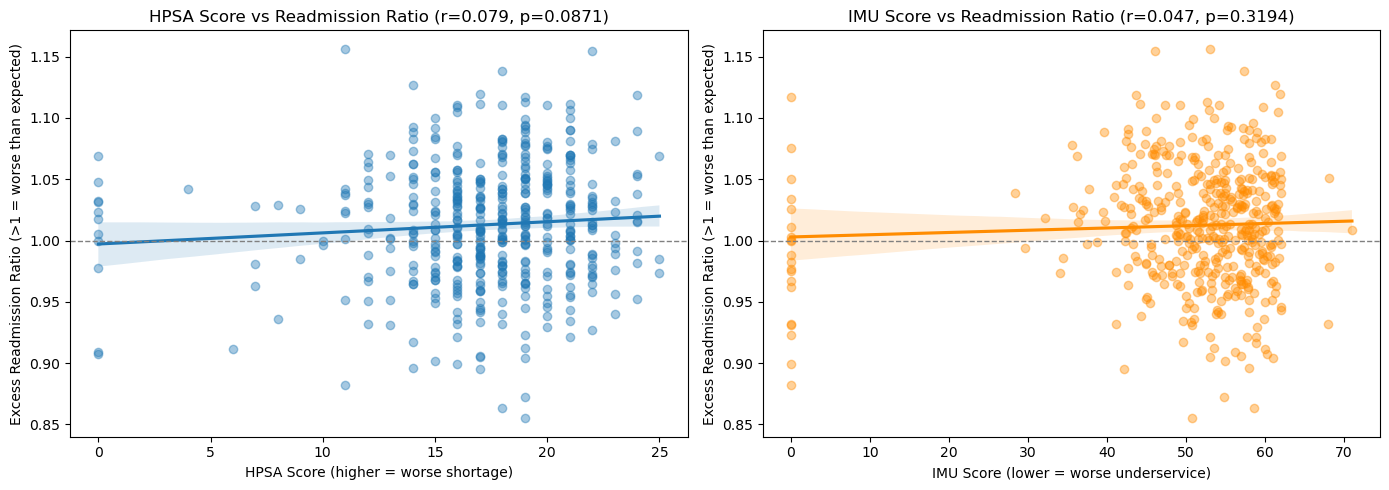

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=hpsa_valid, x='hpsa_score_max', y='excess_readmission_ratio_avg',
            ax=axes[0], scatter_kws={'alpha': 0.4})
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title(f'HPSA Score vs Readmission Ratio (r={r_hpsa:.3f}, p={p_hpsa:.4f})')
axes[0].set_xlabel('HPSA Score (higher = worse shortage)')
axes[0].set_ylabel('Excess Readmission Ratio (>1 = worse than expected)')

sns.regplot(data=imu_valid, x='imu_score_min', y='excess_readmission_ratio_avg',
            ax=axes[1], scatter_kws={'alpha': 0.4}, color='darkorange')
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title(f'IMU Score vs Readmission Ratio (r={r_imu:.3f}, p={p_imu:.4f})')
axes[1].set_xlabel('IMU Score (lower = worse underservice)')
axes[1].set_ylabel('Excess Readmission Ratio (>1 = worse than expected)')

plt.tight_layout()
plt.show()

Neither HPSA Score (r = 0.079, p = 0.087) nor IMU Score (r = 0.047, p = 0.319) showed a statistically significant relationship with cardiac readmission performance. 

Shortage designation severity alone does not predict readmission outcomes, at every shortage level, counties range widely from better than expected to worse than expected performance. 
This suggests factors beyond shortage status alone drive readmission outcomes, which sets up the Question 2 and Question 3 analyses.

Question 2: Do Social Determinants Correlate with Readmission Performance?

Testing income, insurance coverage, and rurality against Excess Readmission Ratio, same 481-county sample and same correlation + p-value approach used for Question 1.

First step: find the exact CHR column names for these three variables, rather than guessing at naming.

In [55]:
candidates = [c for c in chr_south.columns if any(
    term in c.upper() for term in ['INCOME', 'UNINSURED', 'INSURANCE', 'RURAL']
)]
print(candidates)

['# Uninsured', '% Uninsured', '80th Percentile Income', '20th Percentile Income', 'Income Ratio', '% Household Income Required for Child Care Expenses']


In [56]:
candidates_broad = [c for c in chr_south.columns if any(
    term in c.upper() for term in ['RURAL', 'URBAN', 'RUCC', 'POPULATION DENSITY', 'METRO']
)]
print(candidates_broad)

[]


In [57]:
import pandas as pd

xls = pd.ExcelFile('../data/2025 County Health Rankings Data - v4.xlsx')
print(xls.sheet_names)

['Introduction', 'Select Measure Data', 'Select Measure Sources & Years', 'Additional Measure Data', 'Addtl Measure Sources & Years', 'Health Groups']


In [58]:
chr_additional = pd.read_excel('../data/2025 County Health Rankings Data - v4.xlsx',
                                 sheet_name='Additional Measure Data',
                                 header=1)

rural_candidates = [c for c in chr_additional.columns if any(
    term in c.upper() for term in ['RURAL', 'URBAN', 'RUCC', 'POPULATION DENSITY', 'METRO']
)]
print(rural_candidates)

['# Rural Residents', '% Rural']


In [59]:
print(list(chr_additional.columns))

['FIPS', 'State', 'County', 'Life Expectancy', '95% CI - Low', '95% CI - High', 'Life Expectancy (Hispanic (all races))', 'Life Expectancy (Hispanic (all races)) 95% CI - Low', 'Life Expectancy (Hispanic (all races)) 95% CI - High', 'Life Expectancy (Non-Hispanic AIAN)', 'Life Expectancy (Non-Hispanic AIAN) 95% CI - Low', 'Life Expectancy (Non-Hispanic AIAN) 95% CI - High', 'Life Expectancy (Non-Hispanic Asian)', 'Life Expectancy (Non-Hispanic Asian) 95% CI - Low', 'Life Expectancy (Non-Hispanic Asian) 95% CI - High', 'Life Expectancy (Non-Hispanic Black)', 'Life Expectancy (Non-Hispanic Black) 95% CI - Low', 'Life Expectancy (Non-Hispanic Black) 95% CI - High', 'Life Expectancy (Non-Hispanic Native Hawaiian and Other Pacific Islander)', 'Life Expectancy (Non-Hispanic Native Hawaiian and Other Pacific Islander) 95% CI - Low', 'Life Expectancy (Non-Hispanic Native Hawaiian and Other Pacific Islander) 95% CI - High', 'Life Expectancy (Non-Hispanic 2+ races)', 'Life Expectancy (Non-Hispan

In [60]:
print(chr_additional['FIPS'].head())
print(chr_additional['FIPS'].dtype)

0    1000.0
1    1001.0
2    1003.0
3    1005.0
4    1007.0
Name: FIPS, dtype: float64
float64


In [61]:
print("Rows with missing FIPS:", chr_additional['FIPS'].isna().sum())
chr_additional[chr_additional['FIPS'].isna()].head()

Rows with missing FIPS: 1


,FIPS,State,County,Life Expectancy,95% CI - Low,95% CI - High,Life Expectancy (Hispanic (all races)),Life Expectancy (Hispanic (all races)) 95% CI - Low,Life Expectancy (Hispanic (all races)) 95% CI - High,Life Expectancy (Non-Hispanic AIAN),...,95% CI - Low.28,95% CI - High.28,# Children in Single-Parent Households,# Children in Households,% Children in Single-Parent Households,95% CI - Low.29,95% CI - High.29,# Rural Residents,% Rural,Population
3210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
print("Before dropping:", chr_additional.shape[0])
chr_additional = chr_additional.dropna(subset=['FIPS'])
print("After dropping:", chr_additional.shape[0])

chr_additional['FIPS'] = chr_additional['FIPS'].astype(int).astype(str).str.zfill(5)

rural_data = chr_additional[['FIPS', '% Rural']].copy()
master_df = master_df.merge(rural_data, on='FIPS', how='left')

print("Missing % Rural:", master_df['% Rural'].isna().sum())
master_df[['FIPS', 'County', 'State', '% Rural']].head()

Before dropping: 3211
After dropping: 3210
Missing % Rural: 1


,FIPS,County,State,% Rural
0,01001,Autauga,Alabama,40.676813
1,01003,Baldwin,Alabama,37.586455
2,01005,Barbour,Alabama,65.919994
3,01007,Bibb,Alabama,100.000000
4,01009,Blount,Alabama,90.489397


Testing all three social determinants against Excess Readmission Ratio, same 481-county sample and approach as Question 1: Pearson r plus p-value for each.

In [63]:
analysis_df = master_df[master_df['excess_readmission_ratio_avg'].notna()].copy()

determinants = {
    '% Uninsured': 'higher = more uninsured',
    'Income Ratio': 'higher = more income inequality',
    '% Rural': 'higher = more rural'
}

for col, note in determinants.items():
    valid = analysis_df.dropna(subset=[col])
    r, p = stats.pearsonr(valid[col], valid['excess_readmission_ratio_avg'])
    print(f"{col} ({note}): r = {r:.3f}, p = {p:.4f}, n = {valid.shape[0]}")

% Uninsured (higher = more uninsured): r = 0.053, p = 0.2448, n = 481
Income Ratio (higher = more income inequality): r = 0.059, p = 0.1993, n = 477
% Rural (higher = more rural): r = 0.090, p = 0.0489, n = 481


Rurality showed a statistically significant but very weak positive correlation with readmission performance (r = 0.090, p = 0.049); income inequality and uninsured rate showed no significant relationship.

In [64]:
threshold = analysis_df['hpsa_score_max'].quantile(0.75)
print("Top-quartile HPSA score threshold:", threshold)

analysis_df['high_risk'] = analysis_df['hpsa_score_max'] >= threshold
print(analysis_df['high_risk'].value_counts())

Top-quartile HPSA score threshold: 20.0
high_risk
False    349
True     132
Name: count, dtype: int64


In [65]:
high_risk_counties = analysis_df[analysis_df['high_risk']].copy()


err_threshold = high_risk_counties['excess_readmission_ratio_avg'].quantile(0.25)
print("Bottom-quartile ERR threshold among high-risk counties:", err_threshold)

high_risk_counties['hidden_winner'] = high_risk_counties['excess_readmission_ratio_avg'] <= err_threshold
print(high_risk_counties['hidden_winner'].value_counts())

Bottom-quartile ERR threshold among high-risk counties: 0.9838494896105039
hidden_winner
False    99
True     33
Name: count, dtype: int64


In [66]:
winners = high_risk_counties[high_risk_counties['hidden_winner']].sort_values('excess_readmission_ratio_avg')

winners[['FIPS', 'County', 'State', 'hpsa_score_max', 'excess_readmission_ratio_avg', '% Rural', 'Income Ratio']]

,FIPS,County,State,hpsa_score_max,excess_readmission_ratio_avg,% Rural,Income Ratio
942,48135,Ector,Texas,21.0,0.920983,9.090579,4.992403
397,21059,Daviess,Kentucky,22.0,0.927261,26.017307,4.679756
1247,51700,Newport News City,Virginia,20.0,0.929679,0.373697,4.254287
443,21151,Madison,Kentucky,21.0,0.934700,36.185154,4.540360
553,28003,Alcorn,Mississippi,20.0,0.938707,64.122050,5.157020
674,37081,Guilford,North Carolina,23.0,0.939962,14.156686,4.630390
547,22119,Webster,Louisiana,21.0,0.943600,49.711905,5.319909
241,13067,Cobb,Georgia,20.0,0.945714,0.005221,4.262547
344,13275,Thomas,Georgia,20.0,0.949297,44.908075,5.077482
177,12073,Leon,Florida,24.0,0.952357,13.437464,5.196804


33 Hidden Winners identified: high-shortage counties (HPSA score in the top quartile) whose readmission performance still ranks in the best quartile among their high-risk peers.

Notable pattern: winners are not exclusively rural. % Rural ranges from under 1% (Cobb County, GA; Mecklenburg County, NC) to 100% (Letcher County, KY), roughly split between urban and rural counties. This makes sense given how HPSA scores work: a designation can reflect a shortage in a specific underserved facility or population within a county, even a large metro one, rather than requiring the whole county to lack resources.

This suggests overcoming shortage designation isn't purely about rurality or resource scarcity. Something else, possibly hospital density, health system integration, or facility quality, may explain performance better than shortage severity or rurality alone.

I want to point out: this analysis is limited to the 481 counties with reportable CMS data. The 837 counties with no cardiac readmission data at all, 86% of them rural, are addressed separately below and represent a distinct, more severe access problem than underperformance.

In [67]:
no_cms_data = master_df[master_df['excess_readmission_ratio_avg'].isna()].copy()

print("Total counties with no CMS cardiac data:", no_cms_data.shape[0])
print()
print("% Rural distribution among these counties:")
print(no_cms_data['% Rural'].describe())

Total counties with no CMS cardiac data: 837

% Rural distribution among these counties:
count    836.000000
mean      81.230555
std       26.284420
min        0.000000
25%       65.458111
50%      100.000000
75%      100.000000
max      100.000000
Name: % Rural, dtype: float64


In [68]:
rural_no_access = no_cms_data[no_cms_data['% Rural'] >= 50]

print("Rural counties (50%+) with NO cardiac readmission data:", rural_no_access.shape[0])
print("As % of all counties with no CMS data:", round(rural_no_access.shape[0] / no_cms_data.shape[0] * 100, 1), "%")
print()


print("Average % Rural, ALL 1,318 Southern counties:", master_df['% Rural'].mean().round(1))
print("Average % Rural, counties WITH no cardiac data:", no_cms_data['% Rural'].mean().round(1))

Rural counties (50%+) with NO cardiac readmission data: 721
As % of all counties with no CMS data: 86.1 %

Average % Rural, ALL 1,318 Southern counties: 65.7
Average % Rural, counties WITH no cardiac data: 81.2


721 of the 837 counties with no CMS cardiac readmission data (86.1%) are majority rural (50%+). Rural counties are overrepresented in this "invisible" group: the average county with no cardiac data is 81.2% rural, compared to 65.7% across all 1,318 Southern counties.

This does not mean these counties have no hospital, only that no hospital in the county met CMS's minimum case threshold for reporting cardiac readmission measures. Still, this represents a genuine access visibility gap: over half of all Southern rural counties (721 of 1,100 estimated rural counties in the region) cannot be evaluated on cardiac readmission performance at all.

Summary of Findings

-721 of 837 counties with no cardiac readmission data (86.1%) are majority rural, an average of 81.2% rural versus 65.7% across all Southern counties, representing a data visibility gap, not just underperformance.

-Shortage severity (HPSA, IMU) alone does not significantly predict cardiac readmission performance

-Rurality shows a statistically significant but practically negligible correlation (r = 0.090)

-33 "Hidden Winner" counties, high-shortage areas with better than expected readmission outcomes, span both urban and rural counties, suggesting factors beyond shortage or geography drive performance
-These findings shift the dashboard's focus from "where is access worst" to "where is access being overcome, and where access can't even be measured"

Merging the high_risk and hidden_winner flags from the Question 3 analysis back onto master_df, plus adding a has_cms_data flag so the dashboard can distinguish "not a Hidden Winner" from "no data available" for that county.

In [69]:
# Bring high_risk and hidden_winner flags back onto master_df
master_df = master_df.merge(
    analysis_df[['FIPS', 'high_risk']],
    on='FIPS',
    how='left'
)

master_df = master_df.merge(
    high_risk_counties[['FIPS', 'hidden_winner']],
    on='FIPS',
    how='left'
)

# Fill flags: False = not flagged, NaN (no CMS data) also becomes False
# but we keep a separate 'has_cms_data' flag so Power BI can distinguish
# "not a hidden winner" from "we don't know"
master_df['high_risk'] = master_df['high_risk'].fillna(False)
master_df['hidden_winner'] = master_df['hidden_winner'].fillna(False)
master_df['has_cms_data'] = master_df['excess_readmission_ratio_avg'].notna()

print("High risk counties:", master_df['high_risk'].sum())
print("Hidden winner counties:", master_df['hidden_winner'].sum())
print("Counties with CMS data:", master_df['has_cms_data'].sum())

High risk counties: 132
Hidden winner counties: 33
Counties with CMS data: 481


C:\Users\gaine\AppData\Local\Temp\ipykernel_34932\2303509991.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master_df['high_risk'] = master_df['high_risk'].fillna(False)
C:\Users\gaine\AppData\Local\Temp\ipykernel_34932\2303509991.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master_df['hidden_winner'] = master_df['hidden_winner'].fillna(False)


In [70]:
master_df['high_risk'] = master_df['high_risk'].astype('boolean').fillna(False)
master_df['hidden_winner'] = master_df['hidden_winner'].astype('boolean').fillna(False)

In [71]:
master_df.to_csv('../data/master_df_dashboard.csv', index=False)
print("Exported:", master_df.shape)

Exported: (1318, 239)


I'm pulling the official county centroid coordinates (latitude/longitude) from the U.S. Census Bureau's Gazetteer file, matched by FIPS code,so Power BI can plot each county precisely instead of guessing from county names.

In [72]:
import pandas as pd

gaz_url = "https://www2.census.gov/geo/docs/maps-data/data/gazetteer/2023_Gazetteer/2023_Gaz_counties_national.zip"


county_coords = pd.read_csv(gaz_url, sep='\t', dtype={'GEOID': str})


print(county_coords.columns.tolist())

['USPS', 'GEOID', 'ANSICODE', 'NAME', 'ALAND', 'AWATER', 'ALAND_SQMI', 'AWATER_SQMI', 'INTPTLAT', 'INTPTLONG                                                                                                               ']


In [73]:
import pandas as pd

gaz_url = "https://www2.census.gov/geo/docs/maps-data/data/gazetteer/2023_Gazetteer/2023_Gaz_counties_national.zip"

county_coords = pd.read_csv(gaz_url, sep='\t', dtype={'GEOID': str})

county_coords.columns = county_coords.columns.str.strip()

county_coords = county_coords[['GEOID', 'INTPTLAT', 'INTPTLONG']]

county_coords = county_coords.rename(columns={
    'GEOID': 'FIPS',
    'INTPTLAT': 'latitude',
    'INTPTLONG': 'longitude'
})

county_coords['FIPS'] = county_coords['FIPS'].str.strip()
master_df['FIPS'] = master_df['FIPS'].astype(str).str.zfill(5)

master_df = master_df.merge(county_coords, on='FIPS', how='left')

print("Counties with coordinates:", master_df['latitude'].notna().sum())
print("Counties missing coordinates:", master_df['latitude'].isna().sum())

Counties with coordinates: 1317
Counties missing coordinates: 1


In [74]:
master_df[master_df['latitude'].isna()][['FIPS', 'State', 'County']]

,FIPS,State,County
1225,51515,Virginia,Bedford City


In [75]:
master_df.to_csv('../data/master_df_dashboard.csv', index=False)
print("Exported:", master_df.shape)

Exported: (1318, 241)


In [77]:
import os
print(os.getcwd())

C:\Users\gaine\OneDrive\Desktop\NSS\capstone\notebooks
